# 01 — Exploratory Data Analysis

First look at the NYC TLC HVFHV (high-volume for-hire vehicle, i.e. Uber/Lyft) trip data underlying this platform. Reads directly from the dbt-built DuckDB warehouse (`stg_trips`, `int_trips_enriched`, and the marts) — read-only, no writes from this notebook.

Goal: understand volume, coverage, distributions, and data-quality issues *before* Layer 3 modeling assumes anything about this data.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Resolve relative to this notebook so it works regardless of the Jupyter launch cwd.
DB_PATH = Path.cwd().parent / "data" / "warehouse" / "nyc_rides.duckdb"
con = duckdb.connect(str(DB_PATH), read_only=True)
con.execute("select 1").fetchall()

[(1,)]

## 1. What tables are here, and how big are they?

In [2]:
tables = ["raw_trips", "stg_trips", "int_trips_enriched",
          "zone_hourly_demand", "zone_fare_stats", "zone_pair_flows", "stg_zones"]
row_counts = {t: con.execute(f"select count(*) from {t}").fetchone()[0] for t in tables}
row_counts

{'raw_trips': 8000000,
 'stg_trips': 7998849,
 'int_trips_enriched': 7998849,
 'zone_hourly_demand': 515744,
 'zone_fare_stats': 55715,
 'zone_pair_flows': 1659665,
 'stg_zones': 265}

`stg_trips` has ~1.1k fewer rows than `raw_trips` — that's the staging layer's filter dropping non-positive-fare and >=$1000 outlier-fare trips (see `stg_trips.sql`). `int_trips_enriched` matches `stg_trips` 1:1, so the zone join isn't dropping rows. The marts are much smaller because they're pre-aggregated (by date/hour/zone, by zone pair, etc.).

## 2. Date coverage — is this actually a continuous 6-month window?

In [3]:
coverage = con.execute("""
    select
        min(pickup_at) as min_pickup,
        max(pickup_at) as max_pickup,
        count(distinct pickup_date) as distinct_days
    from int_trips_enriched
""").fetchdf()
coverage

,min_pickup,max_pickup,distinct_days
0,2024-01-01 00:00:04,2024-06-30 23:59:59,92


In [4]:
by_month = con.execute("""
    select date_trunc('month', pickup_date) as month,
           count(distinct pickup_date) as days_present,
           count(*) as trips
    from int_trips_enriched
    group by 1
    order by 1
""").fetchdf()
by_month

,month,days_present,trips
0,2024-01-01,31,2575526
1,2024-03-01,31,2787214
2,2024-06-01,30,2636109


**Data quality finding:** the timestamp range spans 2024-01-01 through 2024-06-30 (a 182-day window), but only **92 distinct dates** actually have trips — all of January, all of March, and all of June, with **February, April, and May entirely missing**. This isn't a sparse-day gap, it's whole months absent. Any daily/weekly seasonality analysis or chronological train/val/test split (Rule 3) needs to treat this as three separate contiguous chunks, not one continuous 6-month series — a naive `date_range` reindex or a rolling window that crosses one of these gaps will silently produce garbage (e.g. a 7-day rolling average computed across the Jan→Mar boundary).

## 3. Missingness and basic sanity checks

In [5]:
sanity = con.execute("""
    select
        count(*) as n_rows,
        sum(case when pickup_borough is null then 1 else 0 end) as null_pickup_borough,
        sum(case when dropoff_borough is null then 1 else 0 end) as null_dropoff_borough,
        sum(case when avg_speed_mph is null then 1 else 0 end) as null_speed,
        sum(case when trip_distance = 0 then 1 else 0 end) as zero_distance,
        sum(case when trip_distance > 100 then 1 else 0 end) as distance_over_100mi,
        sum(case when trip_duration_minutes <= 0 then 1 else 0 end) as nonpositive_duration,
        sum(case when trip_duration_minutes > 180 then 1 else 0 end) as duration_over_3h,
        sum(case when avg_speed_mph > 80 then 1 else 0 end) as speed_over_80mph,
        min(total_amount) as min_total_amount,
        max(total_amount) as max_total_amount
    from int_trips_enriched
""").fetchdf()
sanity

,n_rows,null_pickup_borough,null_dropoff_borough,null_speed,zero_distance,distance_over_100mi,nonpositive_duration,duration_over_3h,speed_over_80mph,min_total_amount,max_total_amount
0,7998849,0.0,0.0,195.0,1181.0,702.0,195.0,367.0,7.0,1.110223e-16,977.44


Notes on what shows up here:

- No nulls in pickup/dropoff borough — the zone lookup join is complete for all 265 zones.
- `avg_speed_mph` is null for 195 rows: exactly the rows with `trip_duration_minutes <= 0` (the CASE in `int_trips_enriched.sql` returns NULL rather than dividing by zero/negative — correct behavior, but these 195 trips have no usable duration and should be excluded from any duration- or speed-based feature).
- ~1,181 trips have `trip_distance = 0` and ~702 trips exceed 100 miles (max 263 mi) — both plausible (a cancelled-but-charged trip vs. an actual airport-to-far-suburb ride) but worth capping/flagging as outliers before feeding distance into a model.
- `duration_over_3h` (367 trips) and `speed_over_80mph` (7 trips) are rare enough to be outliers, not a systemic problem.
- `min_total_amount` prints as a tiny float (~1e-16) instead of exactly 0 — floating-point sum-of-components rounding in `total_amount = fare + tolls + bcf + tax + congestion + airport_fee + tip`, not a real negative-fare bug. Harmless for aggregates, but worth knowing if a downstream check ever asserts `total_amount > 0` exactly.

## 4. Trip volume over time

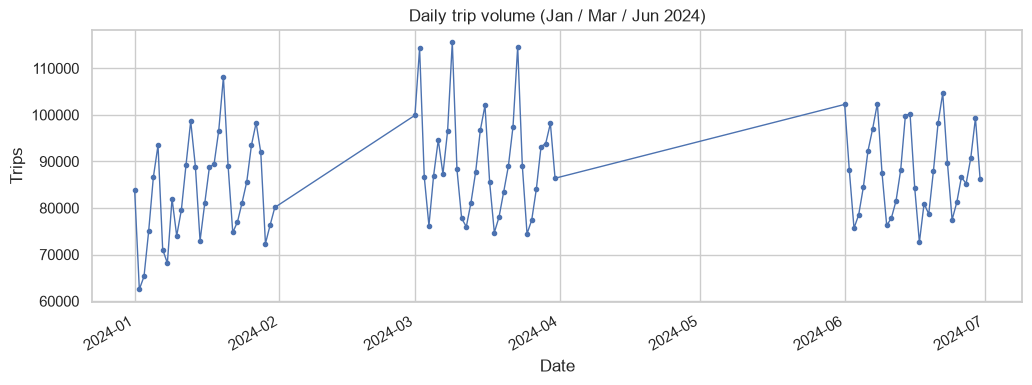

In [6]:
daily = con.execute("""
    select pickup_date, count(*) as trips
    from int_trips_enriched
    group by 1
    order by 1
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["pickup_date"], daily["trips"], marker=".", linewidth=1)
ax.set_title("Daily trip volume (Jan / Mar / Jun 2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Trips")
fig.autofmt_xdate()
plt.show()

Matplotlib connects across the missing months since the x-axis is just the 92 present dates — visually this looks continuous, but per the coverage check above it is *not*: there are ~60-day gaps between the January, March, and June blocks. Within each block, volume is fairly stable day to day (roughly 60k–95k trips/day) with dips that line up with weekends/holidays (e.g. New Year's Day Jan 1).

## 5. Hour-of-day and day-of-week patterns

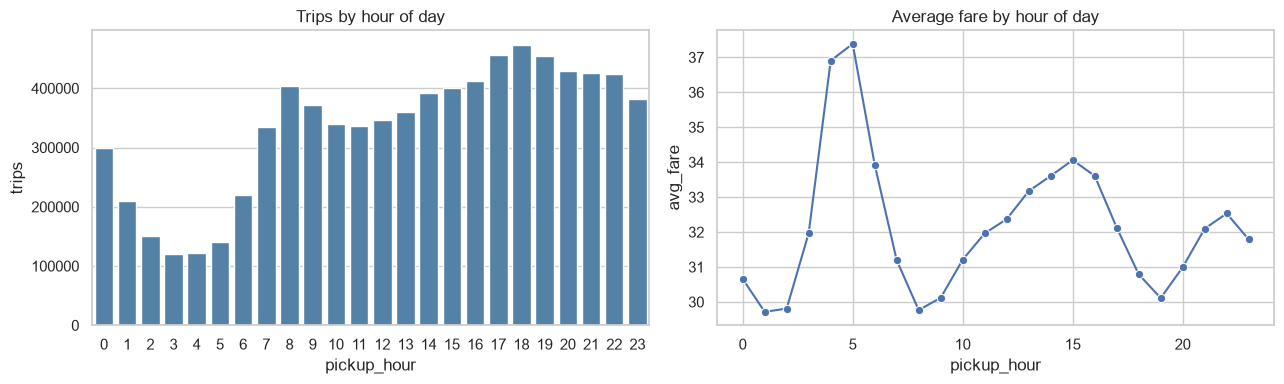

In [7]:
by_hour = con.execute("""
    select pickup_hour, count(*) as trips, avg(total_amount) as avg_fare
    from int_trips_enriched
    group by 1
    order by 1
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=by_hour, x="pickup_hour", y="trips", color="steelblue", ax=axes[0])
axes[0].set_title("Trips by hour of day")
sns.lineplot(data=by_hour, x="pickup_hour", y="avg_fare", marker="o", ax=axes[1])
axes[1].set_title("Average fare by hour of day")
plt.tight_layout()
plt.show()

Clear diurnal shape: a trough at 3–4am (~120k trips), a morning ramp, and an evening peak around 5–6pm (~470k trips) — the expected commute/nightlife pattern for a for-hire-vehicle dataset. Average fare has its own shape though, and it *doesn't* track volume: fares are highest in the 3–6am window (~$34–$37) when volume is lowest, likely airport/long-distance overnight rides and reduced competition/surge, then dip back down through the low-$30s during the high-volume daytime/evening hours. Volume and price are not simply correlated here — worth carrying into any demand-vs-fare modeling.

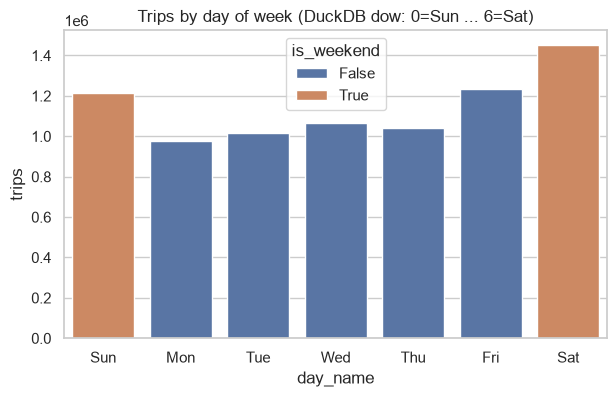

In [8]:
by_dow = con.execute("""
    select pickup_day_of_week, is_weekend, count(*) as trips
    from int_trips_enriched
    group by 1, 2
    order by 1
""").fetchdf()
dow_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
by_dow["day_name"] = by_dow["pickup_day_of_week"].map(dict(enumerate(dow_labels)))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=by_dow, x="day_name", y="trips", hue="is_weekend", dodge=False, ax=ax)
ax.set_title("Trips by day of week (DuckDB dow: 0=Sun ... 6=Sat)")
plt.show()

Saturday and Sunday are the two highest-volume days (~1.45M and ~1.21M trips respectively over the 92 days observed), noticeably above the weekday range (~980k–1.24M). Consistent with `is_weekend` being a useful feature, and Friday (still a weekday flag) sits close to the weekend days — makes sense for a rideshare dataset where Friday night behaves like weekend nightlife.

## 6. Trip distance and fare distributions

With ~8M rows, we bin in SQL rather than pulling every row into pandas for a histogram — cheaper and avoids the DuckDB result set ballooning the notebook's memory.

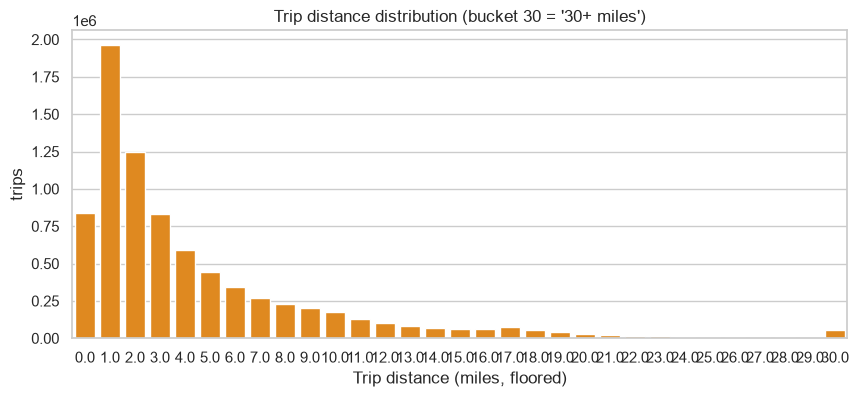

In [9]:
dist_hist = con.execute("""
    select least(floor(trip_distance), 30) as distance_bucket_mi, count(*) as trips
    from int_trips_enriched
    group by 1
    order by 1
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=dist_hist, x="distance_bucket_mi", y="trips", color="darkorange", ax=ax)
ax.set_title("Trip distance distribution (bucket 30 = '30+ miles')")
ax.set_xlabel("Trip distance (miles, floored)")
plt.show()

Heavily right-skewed: the 1–2 mile bucket alone is ~2M trips (the single biggest bucket), and the distribution falls off fast after ~5 miles. The 30+ bucket (~55k trips, ~0.7% of all trips) is a real tail of longer/airport trips, not a rounding artifact — confirmed by the earlier check that 702 trips exceed 100 miles.

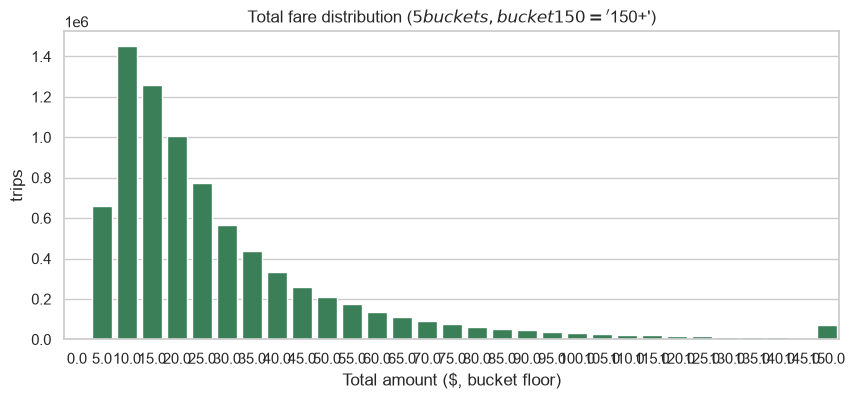

In [10]:
fare_hist = con.execute("""
    select least(floor(total_amount / 5.0) * 5, 150) as fare_bucket, count(*) as trips
    from int_trips_enriched
    group by 1
    order by 1
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=fare_hist, x="fare_bucket", y="trips", color="seagreen", ax=ax)
ax.set_title("Total fare distribution ($5 buckets, bucket 150 = '$150+')")
ax.set_xlabel("Total amount ($, bucket floor)")
plt.show()

Also right-skewed, peaking in the $10–$15 bucket (~1.45M trips), consistent with the distance distribution being dominated by short trips. The $150+ tail (~72k trips) is small but non-trivial — mostly the long-distance/airport trips from the distance histogram above, not noise.

## 7. Where do trips actually start? (zones and boroughs)

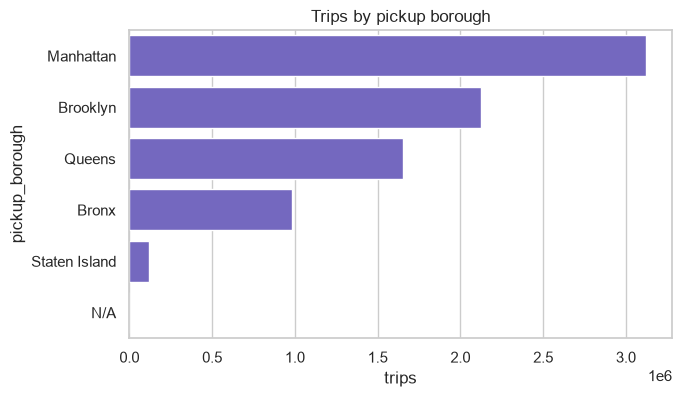

,pickup_borough,trips
0,Manhattan,3121647
1,Brooklyn,2125039
2,Queens,1652840
3,Bronx,982292
4,Staten Island,116711
5,N/A,320


In [11]:
by_borough = con.execute("""
    select pickup_borough, count(*) as trips
    from int_trips_enriched
    group by 1
    order by trips desc
""").fetchdf()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=by_borough, x="trips", y="pickup_borough", color="slateblue", ax=ax)
ax.set_title("Trips by pickup borough")
plt.show()
by_borough

Manhattan leads (~3.12M), but Brooklyn (~2.13M) and Queens (~1.65M) are close behind — for HVFHV specifically (as opposed to yellow cabs), pickups are much more spread across the outer boroughs than the Manhattan-centric stereotype. Staten Island is tiny (~117k) and there are 320 trips tagged pickup borough `N/A` (zone name "Outside of NYC" — airports/service areas outside the five boroughs in the TLC zone lookup, not a join failure).

In [12]:
top_zones = con.execute("""
    select pickup_zone, pickup_borough, count(*) as trips
    from int_trips_enriched
    group by 1, 2
    order by trips desc
    limit 10
""").fetchdf()
top_zones

,pickup_zone,pickup_borough,trips
0,LaGuardia Airport,Queens,149324
1,JFK Airport,Queens,147174
2,East Village,Manhattan,108876
3,Crown Heights North,Brooklyn,106477
4,Times Sq/Theatre District,Manhattan,99315
5,Midtown Center,Manhattan,93364
6,TriBeCa/Civic Center,Manhattan,91947
7,East Chelsea,Manhattan,89301
8,Bushwick South,Brooklyn,87405
9,West Chelsea/Hudson Yards,Manhattan,86254


LaGuardia and JFK airports top the list individually (~149k and ~147k trips) — makes sense as single high-throughput pickup points, and is exactly the kind of "real hub, not just aggregated borough volume" structure the PageRank hub analysis (`algorithms/graph/pagerank_hubs.py`) should be checked against. The rest of the top 10 is a mix of Manhattan nightlife/business zones (East Village, Times Sq/Theatre District, Midtown Center) and Brooklyn residential/nightlife zones (Crown Heights North, Bushwick South) — not a single-borough story.

## 8. Carrier mix

`hvfhs_license_num` identifies the platform: HV0002=Juno, HV0003=Uber, HV0004=Via, HV0005=Lyft.

In [13]:
carriers = con.execute("""
    select hvfhs_license_num, count(*) as trips
    from int_trips_enriched
    group by 1
    order by trips desc
""").fetchdf()
carriers["share"] = carriers["trips"] / carriers["trips"].sum()
carriers

,hvfhs_license_num,trips,share
0,HV0003,5922445,0.740412
1,HV0005,2076404,0.259588


Only two carriers actually appear in this dataset: HV0003 (Uber, ~74% of trips) and HV0005 (Lyft, ~26%). No Juno or Via rows at all — worth knowing if any downstream code assumes all four HVFHV license codes are present.

## 9. Summary — what this means for Layer 3 modeling

- **Coverage gap is the headline issue.** Data exists only for January, March, and June 2024 — February, April, and May are entirely absent. Any chronological split (Rule 3) or rolling-window feature must respect these three blocks as separate contiguous ranges; treating the 6-month span as one continuous series will silently corrupt lag/rolling features across the gaps.
- Strong, well-behaved diurnal (trough ~3–4am, peak ~5–6pm) and day-of-week (weekend/Friday-night lift) seasonality — good signal for the EWMA/XGBoost/LSTM ladder to actually learn.
- Average fare does *not* move in lockstep with volume (overnight fares are highest despite lowest volume) — a pure volume-driven fare model would miss this.
- Trip distance and fare are both heavily right-skewed with a small but real long-trip/airport tail (>100 mi, $150+) — worth a log transform or explicit outlier cap before regression/tree models, rather than dropping the tail outright since it's genuine airport traffic, not corrupt data.
- 195 rows have unusable (non-positive) trip duration and therefore null speed — filter these out of any duration/speed feature rather than imputing.
- Only Uber and Lyft appear (no Juno/Via) — fine for this project's scope, just don't assume all four HVFHV carriers are represented if reusing this analysis on a different data pull.
- LaGuardia and JFK are the two single busiest pickup zones by a wide margin over any non-airport zone — a natural sanity check for whether `pagerank_hubs.py` picks up airport structure rather than just raw volume.